# Thermobar tutorial
## this tutorial was designed for the Lamont virtual computational volcanology course

In [1]:
### You need to install Thermobar once on your machine, if you haven't done this yet, uncomment the line below (remove the #)

In [2]:
!pip install Thermobar


[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# This cell loads in all the packages you may want
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Thermobar as pt
# Needs to be 1.0.54 for this tutorial due to new added features. 
# If you have an older version, run !pip install Thermobar --upgrade, restart your kernel, and run down here again
pt.__version__

'1.0.56'

## Load in data
- The function "import_excel" allows you to specify the name of the excel file and the sheet name.
- Data should have the headings SiO2_Liq, TiO2_Liq etc. etc. The order of headings doesn't matter.
- As in the 5 min intro example, you could also have no _Liq in the headings, and load them in the functoin using suffix="_Liq"
- You can also have any other columns, e.g., estimate of pressure from any other proxy (melt inclusions, geophysics), and anything else you might want to plot (e.g., latitude, longitude)

In [4]:
out=pt.import_excel('Lamont_example_data.xlsx', sheet_name="Liquid_only")
my_input=out['my_input']
myLiquids1=out['Liqs']
myLiquids1.head()

,SiO2_Liq,TiO2_Liq,Al2O3_Liq,FeOt_Liq,MnO_Liq,MgO_Liq,CaO_Liq,Na2O_Liq,K2O_Liq,Cr2O3_Liq,P2O5_Liq,H2O_Liq,Fe3Fet_Liq,NiO_Liq,CoO_Liq,CO2_Liq,Sample_ID_Liq
0,57.023602,0.623106,16.332899,4.36174,0.103851,4.19180,6.94858,3.59702,0.896895,0.000000,0.226584,5.59,0.2,0.0,0.0,0.0,0
1,57.658600,0.654150,17.194799,3.90621,0.084105,2.86892,5.91538,3.85948,1.018600,0.000000,0.214935,6.55,0.2,0.0,0.0,0.0,1
2,60.731201,0.862054,17.144199,4.07781,0.077488,2.50867,5.22075,4.45556,1.414160,0.000000,0.319638,3.14,0.2,0.0,0.0,0.0,2
3,61.532799,0.440860,16.508801,3.32990,0.037520,1.64150,4.34294,4.40860,1.407000,0.000000,0.215740,6.20,0.2,0.0,0.0,0.0,3
4,52.969101,0.803412,17.563000,5.93217,0.149472,3.78351,7.65110,3.80219,0.551178,0.037368,0.196182,6.58,0.2,0.0,0.0,0.0,4


## Calculate temperatures using one equation - Say Tom Shea's new equation

In [5]:
# Options for different thermometers laid out in the "equationT" =
help(pt.calculate_liq_only_temp)

Help on function calculate_liq_only_temp in module Thermobar.liquid_thermometers:

calculate_liq_only_temp(*, liq_comps, equationT, P=None, H2O_Liq=None, print=False)
     Liquid-only thermometery. Returns a temperature in Kelvin.
    
    Parameters
     -------
    
     liq_comps: pandas.DataFrame
         liquid compositions with column headings SiO2_Liq, MgO_Liq etc.
    
     equationT: str
         If has _sat at the end, represents the saturation surface of that mineral.
    
         Equations from Putirka et al. (2016).
             | T_Put2016_eq3_amp_sat (saturation surface of amphibole)
    
         Equations from Putirka (2008) and older studies:
    
             | T_Put2008_eq13
             | T_Put2008_eq14
             | T_Put2008_eq15
             | T_Put2008_eq16
             | T_Put2008_eq34_cpx_sat
             | T_Put1999_cpx_sat
             * Following 3 thermometers are adaptations of olivine-liquid thermometers with  DMg calculated using Beattie 1993,
      

In [6]:
T_Shea2022=pt.calculate_liq_only_temp(liq_comps=myLiquids1,  equationT="T_Shea2022_MgO")-273.15 # convert to Celcius
# In jupyter lab/notebooks, outputs don't automatically display, 
# but it prints the last line in each cell
T_Shea2022

0    1105.866162
1    1077.821106
2    1070.183806
3    1051.799800
4    1097.210411
5    1086.344566
6    1073.715089
7    1107.542024
8    1084.010021
9    1130.398375
Name: MgO_Liq, dtype: float64

## Now lets do calculations with all equations

In [7]:
All_Liq_eqs=pt.calculate_liq_only_temp_all_eqs(liq_comps=myLiquids1, P=3)
pd.DataFrame(All_Liq_eqs)

,T_Put2008_eq13,T_Put2008_eq14,T_Put2008_eq15,T_Put2008_eq16,T_Put2008_eq34_cpx_sat,T_Put1999_cpx_sat,T_Put2008_eq19_BeattDMg,T_Put2008_eq21_BeattDMg,T_Put2008_eq22_BeattDMg,T_Sug2000_eq1,...,T_Sug2000_eq3_cpx,T_Sug2000_eq3_pig,T_Sug2000_eq6a,T_Sug2000_eq6b,T_Helz1987_MgO,T_Helz1987_CaO,T_Montierth1995_MgO,T_Shea2022_MgO,T_Molina2015_amp_sat,T_Put2016_eq3_amp_sat
0,1377.794343,1311.810552,1327.968315,1345.406921,1327.554044,1405.600880,1407.619205,1261.483165,1299.943825,1407.330567,...,1401.899035,1404.597895,1418.294645,1426.117935,1371.405182,1356.496424,1381.561403,1379.016162,1295.748691,1251.561138
1,1343.002598,1258.300154,1276.833340,1268.101755,1286.236484,1359.703184,1362.629867,1187.714381,1247.643088,1379.935388,...,1375.773130,1376.102677,1393.467320,1405.352509,1344.815294,1339.345308,1351.135162,1350.971106,1273.396993,1248.555001
2,1333.528023,1288.418775,1311.457538,1273.822688,1314.447833,1338.372538,1357.949514,1212.460511,1286.813366,1370.104572,...,1366.397797,1365.877111,1386.404134,1394.666356,1337.574269,1327.814448,1342.849412,1343.333806,1265.302768,1264.414419
3,1310.721450,1219.692587,1237.382728,1247.017160,1248.533863,1288.543662,1319.005829,1117.090195,1210.658317,1352.559072,...,1349.665216,1347.627081,1368.921205,1383.491845,1320.144150,1313.242802,1322.904500,1324.949800,1235.947392,1208.499097
4,1367.056312,1286.326580,1295.191769,1311.650285,1309.962037,1406.316126,1383.099330,1242.823771,1272.915490,1400.066265,...,1394.971303,1397.041899,1411.446601,1419.512309,1363.198550,1368.158263,1372.170729,1370.360411,1284.006408,1257.582093
5,1353.576514,1271.925805,1279.319813,1294.846555,1293.866282,1386.404870,1373.541153,1219.945735,1258.958955,1389.019180,...,1384.436052,1385.551225,1402.751485,1409.252755,1352.896499,1354.232355,1360.382312,1359.494566,1276.545681,1261.829006
6,1337.908813,1259.986177,1266.751571,1276.344344,1280.886401,1360.697849,1360.404014,1197.218923,1249.294479,1375.770326,...,1371.801044,1371.770369,1392.084491,1397.083594,1340.922325,1338.508339,1346.680521,1346.865089,1265.664492,1263.193267
7,1379.873360,1188.427508,1192.239846,1360.368487,1239.219105,1455.877958,1392.233352,1164.099226,1187.145430,1420.756806,...,1414.703209,1418.563257,1425.427634,1439.872159,1372.994089,1367.140013,1383.379554,1380.692024,1298.584873,1223.997661
8,1350.680356,1162.846045,1165.277200,1263.931672,1213.772533,1406.923200,1352.626613,1121.684564,1157.272751,1392.631119,...,1387.880643,1389.308199,1400.678531,1419.259210,1350.683086,1358.034754,1357.849551,1357.160021,1278.772639,1206.409286
9,1408.228173,1342.527240,1353.986454,1365.453893,1359.809968,1443.275371,1415.467685,1312.725171,1324.704243,1431.603415,...,1425.047272,1429.845405,1437.527090,1448.518272,1394.664497,1403.307438,1408.176539,1403.548375,1302.880231,1246.097574


## What about paired analyses?
- Often people care about doing calculations on paired Cpx-Liq pairs (perhaps experiments, perhaps rim-matrix glasses, perhaps host-melt inclusions)

In [8]:
## Lets load some Cpx data
out2=pt.import_excel('Lamont_example_data.xlsx', sheet_name="Cpx-Liq")
my_input2=out2['my_input']
Liqs_with_Cpx=out2['Liqs']
Cpx_with_Liqs=out2['Cpxs']

In [9]:
Liqs_with_Cpx.head()

,SiO2_Liq,TiO2_Liq,Al2O3_Liq,FeOt_Liq,MnO_Liq,MgO_Liq,CaO_Liq,Na2O_Liq,K2O_Liq,Cr2O3_Liq,P2O5_Liq,H2O_Liq,Fe3Fet_Liq,NiO_Liq,CoO_Liq,CO2_Liq,Sample_ID_Liq
0,51.1,0.93,17.5,8.91,0.18,6.09,11.50,3.53,0.17,0.0,0.15,3.8,0.0,0.0,0.0,0.0,0
1,51.5,1.19,19.2,8.70,0.19,4.98,10.00,3.72,0.42,0.0,0.14,6.2,0.0,0.0,0.0,0.0,1
2,59.1,0.54,19.1,5.22,0.19,3.25,7.45,4.00,0.88,0.0,0.31,6.2,0.0,0.0,0.0,0.0,2
3,52.5,0.98,19.2,8.04,0.20,4.99,9.64,4.15,0.21,0.0,0.14,6.2,0.0,0.0,0.0,0.0,3
4,56.2,0.34,20.4,5.88,0.20,2.58,7.18,6.02,1.02,0.0,0.23,6.2,0.0,0.0,0.0,0.0,4


In [10]:
Cpx_with_Liqs.head()

,SiO2_Cpx,TiO2_Cpx,Al2O3_Cpx,FeOt_Cpx,MnO_Cpx,MgO_Cpx,CaO_Cpx,Na2O_Cpx,K2O_Cpx,Cr2O3_Cpx,Sample_ID_Cpx
0,51.5,0.50,3.70,5.18,0.09,15.8,22.8,0.24,0.0,0.66,0
1,50.3,0.73,4.12,5.83,0.00,15.0,22.7,0.24,0.0,0.28,1
2,47.3,1.75,7.85,6.51,0.14,13.1,22.5,0.25,0.0,0.22,2
3,51.1,0.63,4.41,5.66,0.13,15.6,22.6,0.23,0.0,0.27,3
4,51.0,0.56,4.14,7.33,0.20,14.4,22.4,0.31,0.0,0.09,4


## Lets calculate pressure and temperature iteratively

In [11]:
PT_cpx=pt.calculate_cpx_liq_press_temp(cpx_comps=Cpx_with_Liqs, liq_comps=Liqs_with_Cpx,
                                    equationT='T_Put2008_eq33', equationP='P_Put2008_eq30', eq_tests=True)
PT_cpx.head()

Using Fe3FeT from input file to calculate Kd Fe-Mg


,P_kbar_calc,T_K_calc,Eq Tests Neave2017?,Delta_P_kbar_Iter,Delta_T_K_Iter,Delta_Kd_Put2008,Delta_Kd_Mas2013,Delta_EnFs_Mollo13,Delta_EnFs_Put1999,Delta_CaTs_Put1999,...,Delta_EnFs_I_M_Mollo13,CaTs_Pred_Put1999,Delta_CaTs_I_M_Put1999,CrCaTs_Pred_Put1999,Delta_CrCaTs_I_M_Put1999,CaTi_Pred_Put1999,Delta_CaTi_I_M_Put1999,Jd_Pred_Put1999,Delta_Jd_Put1999,Delta_Jd_I_M_Put1999
0,2.530914,1352.408784,True,0.0,0.0,0.027981,0.106599,0.011304,0.009468,0.018174,...,-0.011304,0.012201,-0.018174,0.0,0.009562,0.045314,0.004301,0.016178,0.000878,0.000878
1,1.786845,1290.151507,True,0.0,0.0,0.014591,0.110154,0.009917,0.002832,0.025619,...,-0.009917,0.011198,-0.025619,0.0,0.004122,0.061147,0.016209,0.017420,0.000090,0.000090
2,1.171520,1255.933868,False,0.0,0.0,0.080784,0.193537,0.046615,0.050574,0.077199,...,0.046615,0.014686,-0.077199,0.0,0.003245,0.031201,0.040466,0.018319,0.000234,0.000234
3,2.143416,1292.669093,False,0.0,0.0,0.012502,0.119081,0.015465,0.006444,0.033388,...,-0.015465,0.012439,-0.033388,0.0,0.003909,0.054443,0.013245,0.019323,0.002988,0.002988
4,2.763538,1243.469600,False,0.0,0.0,0.002154,0.115101,0.025085,0.033393,0.033542,...,-0.025085,0.009568,-0.033542,0.0,0.001315,0.054153,0.018201,0.027943,0.005728,0.005728


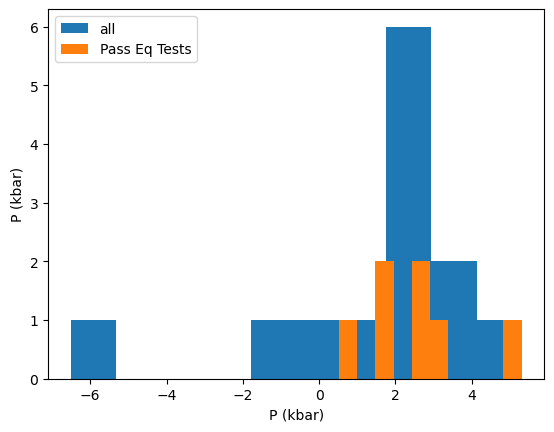

In [12]:
# Plot all pressures
plt.hist(PT_cpx['P_kbar_calc'], label='all');
plt.xlabel('P (kbar)')
plt.ylabel('P (kbar)')
# Now add ones that only pass equilibrium tests of Putirka
plt.hist(PT_cpx['P_kbar_calc'].loc[PT_cpx['Eq Tests Neave2017?']==True], label='Pass Eq Tests');
plt.legend()

## 10 minute Exersize -  Try some different equations - and plot the results and put them in the chat

In [13]:
help(pt.calculate_cpx_liq_press_temp)

Help on function calculate_cpx_liq_press_temp in module Thermobar.clinopyroxene_thermobarometry:

calculate_cpx_liq_press_temp(*, liq_comps=None, cpx_comps=None, meltmatch=None, equationP=None, equationT=None, T=None, P=None, iterations=None, Fe3Fet_Liq=None, H2O_Liq=None, T_K_guess=1300, eq_tests=False)
    Solves simultaneous equations for temperature and pressure
    using clinopyroxene-liquid thermometers and barometers.
    
    
    Parameters
    -------
    
     cpx_comps: pandas.DataFrame (opt, either specify cpx_comps AND liq_comps or meltmatch)
        Clinopyroxene compositions with column headings SiO2_Cpx, MgO_Cpx etc.
    
    liq_comps: pandas.DataFrame
        Liquid compositions with column headings SiO2_Liq, MgO_Liq etc.
    
    Or
    
    meltmatch: pandas.DataFrame
        Combined dataframe of cpx-Liquid compositions
        Used for calculate_cpx_liq_press_temp_matching function.
    
    EquationP: str
        Barometer
        Cpx-Liquid
        |  P_Put1996

## Lets actually get all equations

In [14]:
## If you want to use machine learning - you need to install those packages now!
# You need to grab the latest tag here. https://github.com/PennyWieser/Thermobar_onnx/archive/refs/tags/
#!pip install "https://github.com/PennyWieser/Thermobar_onnx/archive/refs/tags/v.0.0.4.zip"

In [15]:
## Now do all equations
PT_All=pt.calculate_cpx_liq_press_all_eqs(cpx_comps=Cpx_with_Liqs, liq_comps=Liqs_with_Cpx)

We have reset the index on Cpx and Liq comps for the Petrelli expressions
Youve selected a P-independent function
Youve selected a T-independent function
Youve selected a T-independent function
Im normalizing using the Jorgenson method, e.g. 100 total, 2dp
Im normalizing using the Jorgenson method, e.g. 100 total, 2dp
Youve selected a P-independent function
Youve selected a T-independent function
Youve selected a T-independent function


In [16]:
PT_All.head()

,"P_kbar: (P_Neave17, T_Put2008_eq33)","T_K: (P_Neave17, T_Put2008_eq33)","P_kbar: (P_Neave17, T_Put2008_eq34_cpx_sat)","T_K: (P_Neave17, T_Put2008_eq34_cpx_sat)","P_kbar: (P_Put2008_eq30, T_Put2008_eq33)","T_K: (P_Put2008_eq30, T_Put2008_eq33)","P_kbar: (P_Put2008_eq31, T_Put2008_eq33)","T_K: (P_Put2008_eq31, T_Put2008_eq33)","P_kbar: (P_Put2008_eq32c, T_Put2008_eq33)","T_K: (P_Put2008_eq32c, T_Put2008_eq33)",...,"P_kbar: (P_Put2008_eq32c, T_Put2008_eq34)","T_K: (P_Put2008_eq32c, T_Put2008_eq34))",P_kbar: (P2003 P&T),T_K: (P2003 P&T),"T_K: (P_Put1996_eqP1, T_Put1996_eqT2)","P_kbar: (P_Put1996_eqP1, T_Put1996_eqT2)","P_kbar: (Petrelli, 2020)","T_K: (Petrelli, 2020)","P_kbar: (Jorgenson, 2022)","T_K: (Jorgenson, 2022)"
0,0.960631,1344.698427,1.161345,1372.216226,2.530914,1352.408784,2.386186,1351.694450,2.209868,1350.825212,...,4.653251,1402.264846,0.947885,1429.684711,1431.212441,2.587626,2.329420,1365.986364,1.0,1355.15
1,1.583720,1289.239285,1.816406,1323.941135,1.786845,1290.151507,2.624094,1293.925217,1.870946,1290.529579,...,4.453012,1344.888862,0.453851,1388.379217,1410.593746,1.759554,2.445954,1282.522727,2.0,1285.15
2,0.895589,1254.759806,1.055286,1283.601656,1.171520,1255.933868,5.162310,1273.163405,6.281137,1278.078913,...,9.615150,1348.268665,-0.946284,1362.151670,1402.050070,0.278452,2.000000,1238.150000,2.0,1238.15
3,0.952699,1287.319189,1.130722,1317.160073,2.143416,1292.669093,2.225915,1293.041408,2.332966,1293.524848,...,4.859417,1346.713288,-0.021555,1387.134284,1408.805156,1.263705,2.000000,1273.150000,2.0,1273.15
4,3.581562,1246.894077,3.771286,1283.856794,2.763538,1243.469600,2.113770,1240.762861,1.456253,1238.035814,...,3.559098,1282.306231,-1.003005,1307.655434,1373.636951,1.791782,2.000000,1238.150000,2.0,1238.15


## Lets plot our Cpx components on a ternary diagram

In [17]:
# Uncomment this - if it doesnt work, you might need to open your command line and do conda install python-ternary
# !pip install python-ternary

In [18]:
# Calculate ternary coordinates
cpx_comps_tern=pt.tern_points_px(px_comps=Cpx_with_Liqs)
cpx_comps_tern

array([[0.08280532, 0.46696085, 0.45023383],
       [0.09456277, 0.47173123, 0.43370601],
       [0.11092368, 0.49118256, 0.39789376],
       [0.09067082, 0.4638491 , 0.44548008],
       [0.11880401, 0.46514921, 0.41604678],
       [0.09448037, 0.46152526, 0.44399437],
       [0.08385559, 0.4667071 , 0.44943731],
       [0.08891996, 0.46317937, 0.44790067],
       [0.08091157, 0.46311358, 0.45597485],
       [0.08742254, 0.46148638, 0.45109108],
       [0.09561026, 0.45986776, 0.44452198],
       [0.0858223 , 0.46263921, 0.4515385 ],
       [0.09047606, 0.46508008, 0.44444386],
       [0.08626974, 0.46123092, 0.45249935],
       [0.08359815, 0.46346901, 0.45293284]])

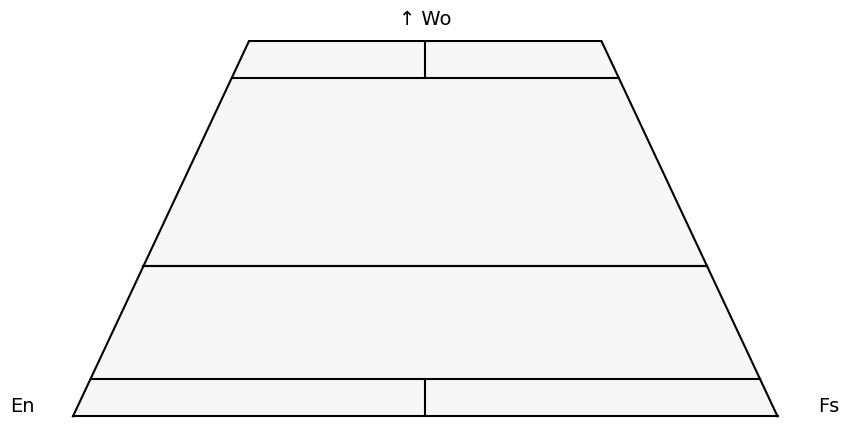

In [19]:
# Now lets build up the plot
fig, tax = pt.plot_px_classification(figsize=(10, 5))

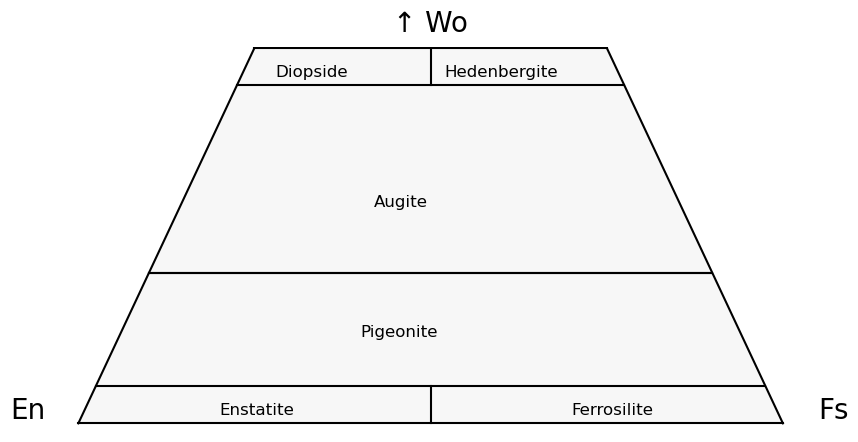

In [20]:
## Perhaps you want labels?
fig, tax = pt.plot_px_classification(figsize=(10, 5), labels=True,
                                     fontsize_component_labels=12,
                                    fontsize_axes_labels=20)

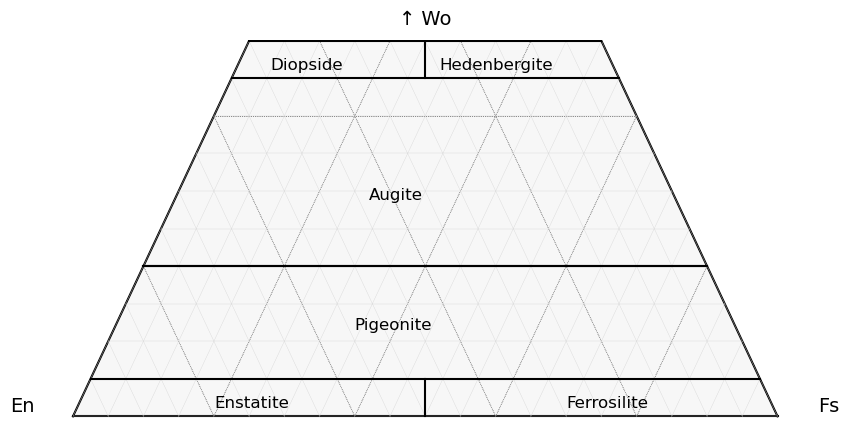

In [21]:
## Perhaps you want a grid
fig, tax = pt.plot_px_classification(figsize=(10, 5), labels=True, fontsize_component_labels=12,
                                     major_grid=True, minor_grid=True)

## Now lets add your data

c:\Users\penny\anaconda3\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


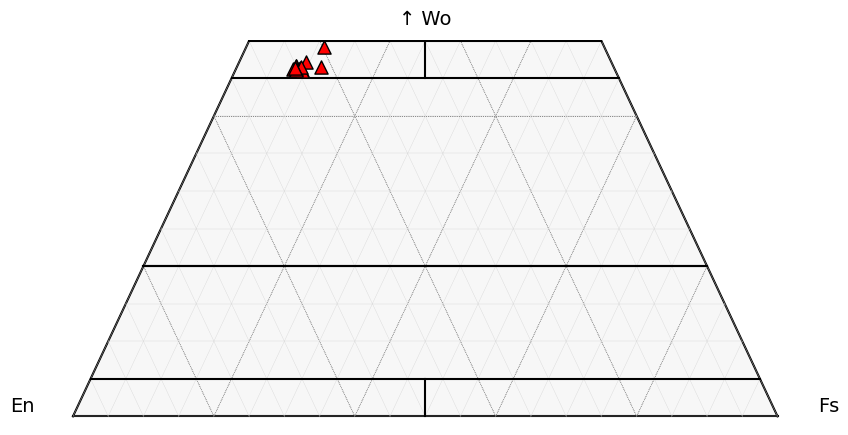

In [22]:
fig, tax = pt.plot_px_classification(figsize=(10, 5),  fontsize_component_labels=12,
                                     major_grid=True, minor_grid=True)

## Now feed in your data we calculated at the start in terms of ternary axes!

tax.scatter(
    cpx_comps_tern,
    edgecolor="k",
    marker="^",
    facecolor="red",
    label='Label1',
   s=90
)

fig.savefig('Cpx_save_fig.png', dpi=300)

## Now lets talk about errors and uncertainty!